# Coursework 3: Part A - RNNs

#### Instructions

Please submit on CATe a zip file named *CW3_RNNs.zip* containing a version of this notebook containing your answers. Write your answers in the cells below each question.


#### Working environment:

Similarly to the previous coursework, we recommend that you use Google Colaboratory in order to train the required networks.

**The deadline for submission is 19:00, Thursday 5th March, 2020**

## Recurrent models coursework

This coursework is separated into a coding and a theory component.

For the first part, you will use the Google Speech Commands v0.02 subset that you used in the tutorial part: http://www.doc.ic.ac.uk/~pam213/co460_files/ 

### Part 1 - Coding (70%)
In this part you will have to:

#### Part 1.1 (20%)

Implement the LSTM RNN cell.

#### Part 1.2 (30%)

- Modify the RNNModel class, such that it is a Bidirectional RNN.
- Compare vanilla RNN, GRU, LSTM, and bidirectional VS unidirectional RNNs and report their performance with respect to accuracy and time cost.

#### Part 1.3 (20%)

Then for your best model you will perform some improvements:
- In terms of architecture optimisation (number of layers, hidden state dimension)
- Better utilisation of the hidden state sequence output by the RNN, for classification.
- Report the improvements you achieved, as well as an explanation for why they worked.

### Part 2 - Theory (30%)

Here you will answer some theoretical questions about RNN training, and CTC -- no detailed proofs and no programming.

### Part 1: Coding

### Dataset

We will be using the Google [*Speech Commands*](https://www.tensorflow.org/tutorials/sequences/audio_recognition) v0.02 [1] dataset.

[1] Warden, P. (2018). [Speech commands: A dataset for limited-vocabulary speech recognition](https://arxiv.org/abs/1804.03209). *arXiv preprint arXiv:1804.03209.*

For the first part, you will use the Google Speech Commands v0.02 subset that you used in the tutorial part: http://www.doc.ic.ac.uk/~pam213/co460_files/ 

Set-up code and imports

In [0]:
import math
import os
from collections import defaultdict

import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset
import numpy as np
from scipy.io.wavfile import read
import librosa
from matplotlib import pyplot as plt

import datetime
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [0]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


Data provider class definition.

Here you can give different configuration to the [mfcc function](https://librosa.github.io/librosa/generated/librosa.feature.mfcc.html). Additional keyword arguments are defined in the [melspectrogram function](https://librosa.github.io/librosa/generated/librosa.feature.melspectrogram.html#librosa.feature.melspectrogram).

One may additionally consider standardising the samples (remove mean, divide by std) or performing data augmentation, e.g., by adding low variance white or noise.

In [0]:
class SpeechCommandsDataset(Dataset):
    """Google Speech Commands dataset."""

    def __init__(self, root_dir, split):
        """
        Args:
            root_dir (string): Directory with all the data files.
            split    (string): In ["train", "valid", "test"].
        """
        self.root_dir = root_dir
        self.split = split

        self.number_of_classes = len(self.get_classes())

        self.class_to_file = defaultdict(list)

        self.valid_filenames = self.get_valid_filenames()
        self.test_filenames = self.get_test_filenames()

        for c in self.get_classes():
            file_name_list = sorted(os.listdir(self.root_dir + "/data_speech_commands_v0.02/" + c))
            for filename in file_name_list:
                if split == "train":
                    if (filename not in self.valid_filenames[c]) and (filename not in self.test_filenames[c]):
                        self.class_to_file[c].append(filename)
                elif split == "valid":
                    if filename in self.valid_filenames[c]:
                        self.class_to_file[c].append(filename)
                elif split == "test":
                    if filename in self.test_filenames[c]:
                        self.class_to_file[c].append(filename)
                else:
                    raise ValueError("Invalid split name.")

        self.filepath_list = list()
        self.label_list = list()
        for cc, c in enumerate(self.get_classes()):
            f_extension = sorted(list(self.class_to_file[c]))
            l_extension = [cc for i in f_extension]
            f_extension = [self.root_dir + "/data_speech_commands_v0.02/" + c + "/" + filename for filename in f_extension]
            self.filepath_list.extend(f_extension)
            self.label_list.extend(l_extension)
        self.number_of_samples = len(self.filepath_list)

    def __len__(self):
        return self.number_of_samples

    def __getitem__(self, idx):
        sample = np.zeros((16000, ), dtype=np.float32)

        sample_file = self.filepath_list[idx]

        sample_from_file = read(sample_file)[1]
        sample[:sample_from_file.size] = sample_from_file
        sample = sample.reshape((16000, ))
        
        ########################################################################
        ## YOU MAY CONFIGURE HERE.
        ########################################################################
        sample = librosa.feature.mfcc(y=sample, sr=16000, hop_length=512, n_fft=2048).transpose().astype(np.float32)
        ########################################################################
        ## DO NOT CONFIGURE BEYOND HERE.
        ########################################################################
        
        label = self.label_list[idx]

        return sample, label

    def get_classes(self):
        return ['one', 'two', 'three']

    def get_valid_filenames(self):
        class_names = self.get_classes()

        class_to_filename = defaultdict(set)
        with open(self.root_dir + "/data_speech_commands_v0.02/validation_list.txt", "r") as fp:
            for line in fp:
                clean_line = line.strip().split("/")

                if clean_line[0] in class_names:
                    class_to_filename[clean_line[0]].add(clean_line[1])

        return class_to_filename

    def get_test_filenames(self):
        class_names = self.get_classes()

        class_to_filename = defaultdict(set)
        with open(self.root_dir + "/data_speech_commands_v0.02/testing_list.txt", "r") as fp:
            for line in fp:
                clean_line = line.strip().split("/")

                if clean_line[0] in class_names:
                    class_to_filename[clean_line[0]].add(clean_line[1])

        return class_to_filename

In [0]:
cd /content/drive/My Drive/Colab Notebooks/Deep Learnign/tutorial6/

/content/drive/My Drive/Colab Notebooks/Deep Learnign/tutorial6


Load Dataset - you may vary batch size.

In [0]:
## MAKE SURE THIS POINTS INSIDE THE DATASET FOLDER.
dataset_folder = "./data" # this should change depending on where you have stored the data files

train_dataset = SpeechCommandsDataset(dataset_folder,
                                      "train")
valid_dataset = SpeechCommandsDataset(dataset_folder,
                                      "valid")

test_dataset = SpeechCommandsDataset(dataset_folder,
                                     "test")

## YOU MAY CHANGE THE BATCH SIZE.
batch_size = 100


num_epochs = 5
valid_every_n_steps = 20
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
valid_loader = torch.utils.data.DataLoader(dataset=valid_dataset,
                                           batch_size=batch_size,
                                           shuffle=False)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [0]:
train_dataset[0][0].shape

(32, 20)

## Part 1.1 (20%)

Finalise the LSTM cell (you can base your code on that of the GRU cell).

You are allowed to use nn.Linear.

In [0]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        
        ########################################################################
        ## START OF YOUR CODE
        ########################################################################
        self.xh = nn.Linear(input_size, hidden_size * 4, bias=bias)
        self.hh = nn.Linear(hidden_size, hidden_size * 4, bias=bias)
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################
        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, input, hx=None):
        if hx is None:
            hx = input.new_zeros(input.size(0), self.hidden_size, requires_grad=False)
            hx = (hx, hx)
            
        
        ########################################################################
        ## START OF YOUR CODE
        ########################################################################

        # Inputs:
        #       input: of shape (batch_size, input_size)
        #       hx: of shape (batch_size, hidden_size) 
        # Outputs:
        #       hy: of shape (batch_size, hidden_size)
        #       cy: of shape (batch_size, hidden_size) 

        hx, cx = hx

        gates = self.xh(input) + self.hh(hx)

        # Get gates (i_t, f_t, g_t, o_t)
        input_gate, forget_gate, cell_gate, output_gate = gates.chunk(4, 1)

        i_t = torch.sigmoid(input_gate)
        f_t = torch.sigmoid(forget_gate)
        g_t = torch.tanh(cell_gate)
        o_t = torch.sigmoid(output_gate)
        
        cy = cx * f_t + i_t * g_t

        hy = o_t * torch.tanh(cy)


        ########################################################################
        ## END OF YOUR CODE
        ########################################################################

        return (hy, cy)

class BasicRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True, nonlinearity="tanh"):
        super(BasicRNNCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.nonlinearity = nonlinearity
        if self.nonlinearity not in ["tanh", "relu"]:
            raise ValueError("Invalid nonlinearity selected for RNN.")

        self.x2h = nn.Linear(input_size, hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, hidden_size, bias=bias)

        self.reset_parameters()
        

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

            
    def forward(self, input, hx=None):
        if hx is None:
            hx = input.new_zeros(input.size(0), self.hidden_size, requires_grad=False)

        ########################################################################
        ## START OF YOUR CODE
        ########################################################################
        
        # Inputs:
        #       input: of shape (batch_size, input_size)
        #       hx: of shape (batch_size, hidden_size)
        # Output:
        #       hy: of shape (batch_size, hidden_size) 

        hy = (self.x2h(input) + self.h2h(hx))

        if self.nonlinearity == "tanh":
            hy = torch.tanh(hy)
        else:
            hy = torch.relu(hy)

        ########################################################################
        ## END OF YOUR CODE
        ########################################################################
            
        return hy

    
    
class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(GRUCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias

        ########################################################################
        ## START OF YOUR CODE
        ########################################################################
        self.x2h = nn.Linear(input_size, 3 * hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, 3 * hidden_size, bias=bias)
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################
        self.reset_parameters()
        

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, input, hx=None):
        if hx is None:
            hx = input.new_zeros(input.size(0), self.hidden_size, requires_grad=False)

        ########################################################################
        ## START OF YOUR CODE
        ########################################################################

        # Inputs:
        #       input: of shape (batch_size, input_size)
        #       hx: of shape (batch_size, hidden_size)
        # Output:
        #       hy: of shape (batch_size, hidden_size) 

        x_t = self.x2h(input)
        h_t = self.h2h(hx)


        x_reset, x_upd, x_new = x_t.chunk(3, 1)
        h_reset, h_upd, h_new = h_t.chunk(3, 1)

        reset_gate = torch.sigmoid(x_reset + h_reset)
        update_gate = torch.sigmoid(x_upd + h_upd)
        new_gate = torch.tanh(x_new + (reset_gate * h_new))

        hy = update_gate * hx + (1 - update_gate) * new_gate 
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################
        
        return hy

In [0]:
class RNNModel(nn.Module):
    def __init__(self, mode, input_size, hidden_size, num_layers, bias, output_size):
        super(RNNModel, self).__init__()
        self.mode = mode
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bias = bias
        self.output_size = output_size
        
        self.rnn_cell_list = nn.ModuleList()
        
        if mode == 'LSTM':
        ########################################################################
        ## START OF YOUR CODE
        ########################################################################
            self.rnn_cell_list.append(LSTMCell(self.input_size,
                                                self.hidden_size,
                                                self.bias))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(LSTMCell(self.hidden_size,
                                                    self.hidden_size,
                                                    self.bias))
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################


        elif mode == 'GRU':
            self.rnn_cell_list.append(GRUCell(self.input_size,
                                              self.hidden_size,
                                              self.bias))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(GRUCell(self.hidden_size,
                                                  self.hidden_size,
                                                  self.bias))

        elif mode == 'RNN_TANH':
            self.rnn_cell_list.append(BasicRNNCell(self.input_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "tanh"))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(BasicRNNCell(self.hidden_size,
                                                       self.hidden_size,
                                                       self.bias,
                                                       "tanh"))

        elif mode == 'RNN_RELU':
            self.rnn_cell_list.append(BasicRNNCell(self.input_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "relu"))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(BasicRNNCell(self.hidden_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "relu"))
        else:
            raise ValueError("Invalid RNN mode selected.")


        self.att_fc = nn.Linear(self.hidden_size, 1)
        self.fc = nn.Linear(self.hidden_size, self.output_size)

        
    def forward(self, input, hx=None):
        if hx is None:
            if torch.cuda.is_available():
                h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size).cuda())
            else:
                h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size))

        else:
             h0 = hx

        outs = []

        ########################################################################
        ## START OF YOUR CODE
        ########################################################################

        #
        # Input of shape (seqence length, batch_size, input_size)
        #
        # Output of shape (batch_size, output_size)
        #

        hidden = list()
        for layer in range(self.num_layers):
            hidden.append(h0[layer, :, :])
        
        for t in range(input.size(1)):

            for layer in range(self.num_layers):

                if self.mode == 'LSTM':
                    
                    if layer == 0:
                        hidden_l = self.rnn_cell_list[layer](
                            input[:, t, :], 
                            (hidden[layer][0],hidden[layer][1])
                            )
                    else:
                        hidden_l = self.rnn_cell_list[layer](
                            hidden[layer - 1][0], 
                            (hidden[layer][0], hidden[layer][1])
                            )

                else:

                    if layer == 0:
                        hidden_l = self.rnn_cell_list[layer](input[:, t, :], hidden[layer])
                    else:
                        hidden_l = self.rnn_cell_list[layer](hidden[layer - 1],hidden[layer])
                    hidden[layer] = hidden_l

                hidden[layer] = hidden_l

            if self.mode == 'LSTM':
                outs.append(hidden_l[0])
            else:
                outs.append(hidden_l)
   
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################

        out = outs[-1].squeeze() # Related to Part 1.3.
        
        out = self.fc(out)
        
        
        return out
    

class BidirRecurrentModel(nn.Module):
    def __init__(self, mode, input_size, hidden_size, num_layers, bias, output_size):
        super(BidirRecurrentModel, self).__init__()
        self.mode = mode
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bias = bias
        self.output_size = output_size
        
        self.rnn_cell_list = nn.ModuleList()
        
        ########################################################################
        ## START OF YOUR CODE
        ########################################################################
        if mode == 'LSTM':
        
            self.rnn_cell_list.append(LSTMCell(self.input_size,
                                              self.hidden_size,
                                              self.bias))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(LSTMCell(self.hidden_size,
                                                    self.hidden_size,
                                                    self.bias))

        elif mode == 'GRU':
            self.rnn_cell_list.append(GRUCell(self.input_size,
                                              self.hidden_size,
                                              self.bias))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(GRUCell(self.hidden_size,
                                                  self.hidden_size,
                                                  self.bias))

        elif mode == 'RNN_TANH':
            self.rnn_cell_list.append(BasicRNNCell(self.input_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "tanh"))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(BasicRNNCell(self.hidden_size,
                                                       self.hidden_size,
                                                       self.bias,
                                                       "tanh"))

        elif mode == 'RNN_RELU':
            self.rnn_cell_list.append(BasicRNNCell(self.input_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "relu"))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(BasicRNNCell(self.hidden_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "relu"))
        else:
            raise ValueError("Invalid RNN mode selected.")

        self.fc = nn.Linear(self.hidden_size * 2, self.output_size)
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################
        
        
    def forward(self, input, hx=None):
        if torch.cuda.is_available():
            h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size).cuda())
        else:
            h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size))
            
        if torch.cuda.is_available():
            hT = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size).cuda())
        else:
            hT = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size))
            
            
        outs = []
        outs_rev = []
        
        ########################################################################
        ## START OF YOUR CODE
        ########################################################################

        #
        # Input of shape (sequence length, batch_size, input_size)
        #
        # Output of shape (batch_size, output_size)

        hidden_forward = list()
        for layer in range(self.num_layers):
            hidden_forward.append(h0[layer, :, :])
            
        hidden_backward = list()
        for layer in range(self.num_layers):
            hidden_backward.append(hT[layer, :, :])
            
        for t in range(input.shape[1]):
            for layer in range(self.num_layers):

                if self.mode == 'LSTM':
                    # If LSTM
                    if layer == 0:
                        # Forward net
                        h_forward_l = self.rnn_cell_list[layer](
                            input[:, t, :], 
                            (hidden_forward[layer][0], hidden_forward[layer][1])
                            )
                        # Backward net
                        h_back_l = self.rnn_cell_list[layer](
                            input[:, -(t + 1), :], 
                            (hidden_backward[layer][0], hidden_backward[layer][1])
                            )
                    else:
                        # Forward net
                        h_forward_l = self.rnn_cell_list[layer](
                            hidden_forward[layer - 1][0], 
                            (hidden_forward[layer][0], hidden_forward[layer][1])
                            )
                        # Backward net
                        h_back_l = self.rnn_cell_list[layer](
                            hidden_backward[layer - 1][0], 
                            (hidden_backward[layer][0], hidden_backward[layer][1])
                            )
                
                else:
                    # If RNN{_TANH/_RELU} / GRU
                    if layer == 0:
                        # Forward net
                        h_forward_l = self.rnn_cell_list[layer](input[:, t, :], hidden_forward[layer])
                        # Backward net
                        h_back_l = self.rnn_cell_list[layer](input[:, -(t + 1), :], hidden_backward[layer])
                    else:
                        # Forward net
                        h_forward_l = self.rnn_cell_list[layer](hidden_forward[layer - 1], hidden_forward[layer])
                        # Backward net
                        h_back_l = self.rnn_cell_list[layer](hidden_backward[layer - 1], hidden_backward[layer])
                    
                    
                hidden_forward[layer] = h_forward_l
                hidden_backward[layer] = h_back_l

            if self.mode == 'LSTM':

                outs.append(h_forward_l[0])
                outs_rev.append(h_back_l[0])

            else:
                outs.append(h_forward_l)
                outs_rev.append(h_back_l)

        ########################################################################
        ## END OF YOUR CODE
        ########################################################################
        out = outs[-1].squeeze()  # Related to question 1.3.
        out_rev = outs_rev[0].squeeze()
        out = torch.cat((out, out_rev), 1)

        out = self.fc(out)
        return out

##Part 1.2 (30%)

In the following, experiment with different RNN architectures (RNN cell types, number of layers, hidden state dimensionality, MFCC configuration, unidirectional VS bidirectional) and report the accuracy (pay also attention to the training and validation cost), as well as training time. 
* What are your justifications for these results?
* On the notebook, leave the execution of your best model.

### Below I have trained several models (one of each kind). I have added a timer for each model as well as I print the losses after the training of each model is finished. The answer of the above question and **ALL** the results are summed up in Section "Answer to Part 1.2". 

Iteration: 20. Loss: 1.0762317180633545. V-Accuracy: 59  T-Accuracy: 59
Iteration: 40. Loss: 0.7209832072257996. V-Accuracy: 62  T-Accuracy: 62
Iteration: 60. Loss: 0.7529563903808594. V-Accuracy: 61  T-Accuracy: 62
Iteration: 80. Loss: 0.5927211046218872. V-Accuracy: 74  T-Accuracy: 73
Iteration: 100. Loss: 0.6701897382736206. V-Accuracy: 73  T-Accuracy: 73
Iteration: 120. Loss: 0.5315871834754944. V-Accuracy: 80  T-Accuracy: 79
Iteration: 140. Loss: 0.43038904666900635. V-Accuracy: 87  T-Accuracy: 86
Iteration: 160. Loss: 0.47370368242263794. V-Accuracy: 89  T-Accuracy: 88
Iteration: 180. Loss: 0.24632200598716736. V-Accuracy: 89  T-Accuracy: 88
Iteration: 200. Loss: 0.2650049030780792. V-Accuracy: 90  T-Accuracy: 90
Iteration: 220. Loss: 0.3535824120044708. V-Accuracy: 87  T-Accuracy: 90
Iteration: 240. Loss: 0.24945774674415588. V-Accuracy: 91  T-Accuracy: 92
Iteration: 260. Loss: 0.24690179526805878. V-Accuracy: 93  T-Accuracy: 92
Iteration: 280. Loss: 0.16291670501232147. V-Accur

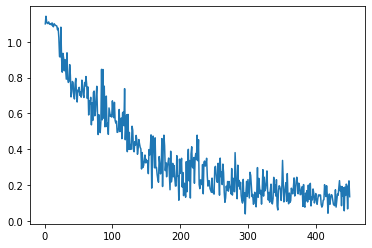

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 128
layer_dim = 3
bias = True

model = BidirRecurrentModel("LSTM", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.8, last_epoch=-1)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))
    #scheduler.step()
end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 0.5131093859672546. V-Accuracy: 68  T-Accuracy: 65
Iteration: 40. Loss: 0.30102404952049255. V-Accuracy: 87  T-Accuracy: 87
Iteration: 60. Loss: 0.372060090303421. V-Accuracy: 91  T-Accuracy: 90
Iteration: 80. Loss: 0.2463005781173706. V-Accuracy: 91  T-Accuracy: 91
Iteration: 100. Loss: 0.14818379282951355. V-Accuracy: 95  T-Accuracy: 95
Iteration: 120. Loss: 0.17756542563438416. V-Accuracy: 95  T-Accuracy: 94
Iteration: 140. Loss: 0.14349347352981567. V-Accuracy: 95  T-Accuracy: 95
Iteration: 160. Loss: 0.08722736686468124. V-Accuracy: 94  T-Accuracy: 95
Iteration: 180. Loss: 0.1114109456539154. V-Accuracy: 94  T-Accuracy: 95
Iteration: 200. Loss: 0.2101454734802246. V-Accuracy: 95  T-Accuracy: 95
Iteration: 220. Loss: 0.3811945617198944. V-Accuracy: 92  T-Accuracy: 95
Iteration: 240. Loss: 0.15730996429920197. V-Accuracy: 96  T-Accuracy: 95
Iteration: 260. Loss: 0.23845699429512024. V-Accuracy: 96  T-Accuracy: 95
Iteration: 280. Loss: 0.04642908275127411. V-Accu

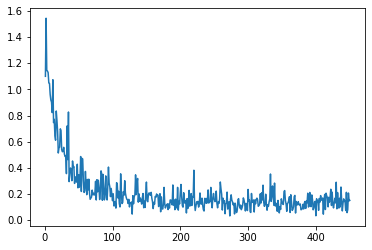

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 128
layer_dim = 3
bias = True

model = BidirRecurrentModel("GRU", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.8, last_epoch=-1)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))
    #scheduler.step()
end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 1.1517521142959595. V-Accuracy: 34  T-Accuracy: 34
Iteration: 40. Loss: 1.133837103843689. V-Accuracy: 32  T-Accuracy: 34
Iteration: 60. Loss: 1.2119895219802856. V-Accuracy: 31  T-Accuracy: 34
Iteration: 80. Loss: 1.1042946577072144. V-Accuracy: 35  T-Accuracy: 34
Iteration: 100. Loss: 1.124163031578064. V-Accuracy: 34  T-Accuracy: 34
Iteration: 120. Loss: 1.1017652750015259. V-Accuracy: 34  T-Accuracy: 34
Iteration: 140. Loss: 1.0722193717956543. V-Accuracy: 30  T-Accuracy: 34
Iteration: 160. Loss: 1.1297584772109985. V-Accuracy: 34  T-Accuracy: 34
Iteration: 180. Loss: 1.1302293539047241. V-Accuracy: 30  T-Accuracy: 34
Iteration: 200. Loss: 1.1339774131774902. V-Accuracy: 34  T-Accuracy: 34
Iteration: 220. Loss: 1.0841697454452515. V-Accuracy: 34  T-Accuracy: 34
Iteration: 240. Loss: 1.114687442779541. V-Accuracy: 34  T-Accuracy: 34
Iteration: 260. Loss: 1.095431923866272. V-Accuracy: 34  T-Accuracy: 34
Iteration: 280. Loss: 1.1020852327346802. V-Accuracy: 34  T

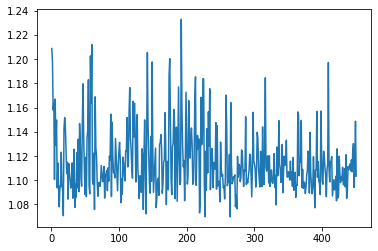

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 32
layer_dim = 1
bias = True

model = BidirRecurrentModel("RNN_TANH", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))

end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 1.27803373336792. V-Accuracy: 34  T-Accuracy: 35
Iteration: 40. Loss: 1.125725269317627. V-Accuracy: 39  T-Accuracy: 39
Iteration: 60. Loss: 1.0359898805618286. V-Accuracy: 40  T-Accuracy: 40
Iteration: 80. Loss: 1.1332286596298218. V-Accuracy: 39  T-Accuracy: 40
Iteration: 100. Loss: 1.1858491897583008. V-Accuracy: 40  T-Accuracy: 39
Iteration: 120. Loss: 1.0995029211044312. V-Accuracy: 41  T-Accuracy: 39
Iteration: 140. Loss: 1.117680549621582. V-Accuracy: 41  T-Accuracy: 41
Iteration: 160. Loss: 1.0212687253952026. V-Accuracy: 41  T-Accuracy: 40
Iteration: 180. Loss: 1.0914868116378784. V-Accuracy: 41  T-Accuracy: 40
Iteration: 200. Loss: 1.0669444799423218. V-Accuracy: 43  T-Accuracy: 42
Iteration: 220. Loss: 1.0451778173446655. V-Accuracy: 44  T-Accuracy: 43
Iteration: 240. Loss: 1.0726006031036377. V-Accuracy: 43  T-Accuracy: 43
Iteration: 260. Loss: 1.041282057762146. V-Accuracy: 43  T-Accuracy: 43
Iteration: 280. Loss: 0.9864687323570251. V-Accuracy: 42  T-

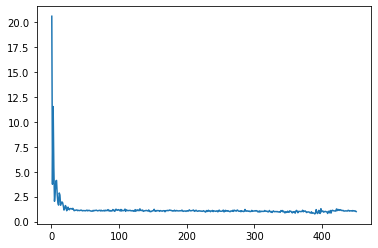

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 32
layer_dim = 1
bias = True

model = BidirRecurrentModel("RNN_RELU", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.8, last_epoch=-1)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))
    #scheduler.step()
end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 0.8360503911972046. V-Accuracy: 65  T-Accuracy: 64
Iteration: 40. Loss: 0.5238761305809021. V-Accuracy: 83  T-Accuracy: 84
Iteration: 60. Loss: 0.37282097339630127. V-Accuracy: 84  T-Accuracy: 83
Iteration: 80. Loss: 0.1925034373998642. V-Accuracy: 92  T-Accuracy: 91
Iteration: 100. Loss: 0.17248761653900146. V-Accuracy: 94  T-Accuracy: 94
Iteration: 120. Loss: 0.06836158037185669. V-Accuracy: 93  T-Accuracy: 94
Iteration: 140. Loss: 0.1177440732717514. V-Accuracy: 94  T-Accuracy: 94
Iteration: 160. Loss: 0.07203137874603271. V-Accuracy: 95  T-Accuracy: 94
Iteration: 180. Loss: 0.07249867171049118. V-Accuracy: 96  T-Accuracy: 95
Iteration: 200. Loss: 0.20838169753551483. V-Accuracy: 94  T-Accuracy: 95
Iteration: 220. Loss: 0.08121521025896072. V-Accuracy: 96  T-Accuracy: 96
Iteration: 240. Loss: 0.15174445509910583. V-Accuracy: 93  T-Accuracy: 96
Iteration: 260. Loss: 0.07107547670602798. V-Accuracy: 95  T-Accuracy: 96
Iteration: 280. Loss: 0.13561008870601654. V-A

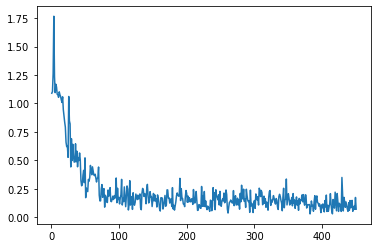

In [0]:
##################################
#     THIS IS MY BEST MODEL      #
##################################

seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 128
layer_dim = 3
bias = True

model = RNNModel("GRU", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))
    
end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 0.8725066184997559. V-Accuracy: 58  T-Accuracy: 57
Iteration: 40. Loss: 0.817105770111084. V-Accuracy: 72  T-Accuracy: 70
Iteration: 60. Loss: 0.6404378414154053. V-Accuracy: 72  T-Accuracy: 71
Iteration: 80. Loss: 0.7211856245994568. V-Accuracy: 65  T-Accuracy: 71
Iteration: 100. Loss: 0.4294549822807312. V-Accuracy: 83  T-Accuracy: 83
Iteration: 120. Loss: 0.45062363147735596. V-Accuracy: 84  T-Accuracy: 83
Iteration: 140. Loss: 0.44505512714385986. V-Accuracy: 86  T-Accuracy: 86
Iteration: 160. Loss: 0.30253681540489197. V-Accuracy: 90  T-Accuracy: 90
Iteration: 180. Loss: 0.3653779625892639. V-Accuracy: 88  T-Accuracy: 90
Iteration: 200. Loss: 0.1728953719139099. V-Accuracy: 87  T-Accuracy: 90
Iteration: 220. Loss: 0.35531967878341675. V-Accuracy: 87  T-Accuracy: 90
Iteration: 240. Loss: 0.3087081015110016. V-Accuracy: 88  T-Accuracy: 90
Iteration: 260. Loss: 0.2687135636806488. V-Accuracy: 91  T-Accuracy: 92
Iteration: 280. Loss: 0.28072232007980347. V-Accurac

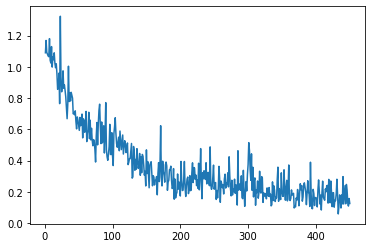

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 128
layer_dim = 3
bias = True

model = RNNModel("LSTM", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))

end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 1.0962218046188354. V-Accuracy: 34  T-Accuracy: 34
Iteration: 40. Loss: 1.1337745189666748. V-Accuracy: 34  T-Accuracy: 34
Iteration: 60. Loss: 1.0950849056243896. V-Accuracy: 30  T-Accuracy: 34
Iteration: 80. Loss: 1.1059304475784302. V-Accuracy: 34  T-Accuracy: 33
Iteration: 100. Loss: 1.104335904121399. V-Accuracy: 34  T-Accuracy: 34
Iteration: 120. Loss: 1.1022131443023682. V-Accuracy: 34  T-Accuracy: 34
Iteration: 140. Loss: 1.0902279615402222. V-Accuracy: 34  T-Accuracy: 33
Iteration: 160. Loss: 1.0961531400680542. V-Accuracy: 34  T-Accuracy: 34
Iteration: 180. Loss: 1.120749831199646. V-Accuracy: 34  T-Accuracy: 34
Iteration: 200. Loss: 1.1004949808120728. V-Accuracy: 34  T-Accuracy: 33
Iteration: 220. Loss: 1.0935288667678833. V-Accuracy: 34  T-Accuracy: 33
Iteration: 240. Loss: 1.0934758186340332. V-Accuracy: 34  T-Accuracy: 33
Iteration: 260. Loss: 1.1164530515670776. V-Accuracy: 34  T-Accuracy: 33
Iteration: 280. Loss: 1.0978000164031982. V-Accuracy: 34 

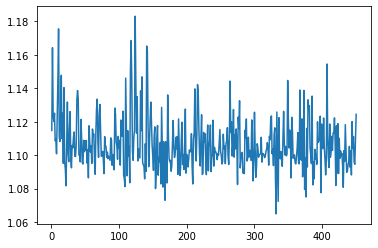

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 32
layer_dim = 1
bias = True

model = RNNModel("RNN_TANH", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))

end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

Iteration: 20. Loss: 3.1427161693573. V-Accuracy: 34  T-Accuracy: 33
Iteration: 40. Loss: 1.7903803586959839. V-Accuracy: 38  T-Accuracy: 37
Iteration: 60. Loss: 1.3655369281768799. V-Accuracy: 38  T-Accuracy: 37
Iteration: 80. Loss: 1.146276831626892. V-Accuracy: 38  T-Accuracy: 37
Iteration: 100. Loss: 1.290700078010559. V-Accuracy: 40  T-Accuracy: 38
Iteration: 120. Loss: 1.079376220703125. V-Accuracy: 39  T-Accuracy: 38
Iteration: 140. Loss: 0.9937206506729126. V-Accuracy: 40  T-Accuracy: 39
Iteration: 160. Loss: 1.0297757387161255. V-Accuracy: 40  T-Accuracy: 40
Iteration: 180. Loss: 1.2602035999298096. V-Accuracy: 41  T-Accuracy: 41
Iteration: 200. Loss: 1.097063660621643. V-Accuracy: 39  T-Accuracy: 41
Iteration: 220. Loss: 1.12583327293396. V-Accuracy: 41  T-Accuracy: 39
Iteration: 240. Loss: 1.1990540027618408. V-Accuracy: 40  T-Accuracy: 39
Iteration: 260. Loss: 1.0334261655807495. V-Accuracy: 41  T-Accuracy: 39
Iteration: 280. Loss: 1.0596768856048584. V-Accuracy: 40  T-Accu

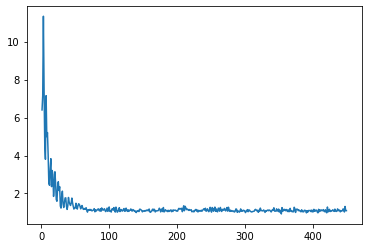

In [0]:
seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 32
layer_dim = 1
bias = True

model = RNNModel("RNN_RELU", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
start = datetime.datetime.now() # TIMER
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))

end = datetime.datetime.now()
total_run_time = end - start
# PLOT LOSS AND PRINT EXECUTION TIME
print("Total Run Time : {}".format(total_run_time))
plt.plot(range(1,len(loss_list)+1), loss_list)

In [0]:
 cd /content/drive/"My Drive"/"Colab Notebooks"/"Deep Learning"/cw_3

## Answer to Part 1.2:

After many different implementations of various models, I decided to present the results of the models above in order to compare them. The accuracy results, as well as the training times, are summarised on the table below for an easier comparison:

* Firstly, as was expected, RNN (either with TANH or ReLU) implementations, either Biderectional or not, they performed the worse. No matter what set of hyperparameters I chose(e.g. I tried increasing/deacreasing the hidden dimension as well as the layer dimensio, etc), the final validation and test performances were too low (just above 33.333% which is the random accuracy) as well as the loss didn't significally dropped, as can be seen on the plots above. This poor performance  is due to the fact that RNNs suffer from the vanishing/exploding gradients problem caused by the continuous application of the activation functions.

* Compared to RNNs, LSTMs and GRUs performed significally better (in terms of validation and test accuracies). This can be axplained by two factors; first, LSTMs and GRUs can overcome the vanishing and exploding gradients problem due to the fact that they use gates to regulate the backpropagated gradients and thus, the networks can actually learn. Second, they have more training parameters and therefore, can learn more information from the training data.

* Comparing the LSTMs and GRUs, we can observe from the second figure below that the loss of the GRUs drops much faster than it does for the LSTMs, which means that GRUs achieve a faster learning than LSTMs. Moreover, the GRUs presented here, they finish training in less time than the LSTMs. Both of these observations were expected as GRUs have less trainable parameters. In theory, LSTMs can perform better at tasks where there are long-term dependancies among the data, which is not quite the case here, since our data contains only 3 classes of a single speech command, "one", "two", "three". If out training task was to train on whole sentences, probably LSTMs would perform better than GRUs as there are long-term dependancies among words in a sentence.

* While Bidirectional and Unidirectional LSTMs and GRUs performed equally well, the best model was the implementation of the Uniderectional GRU model, as it achieved the best test and validation scores in the minimum training time (11 minutes and 43 seconds).

Accuracies of Final models



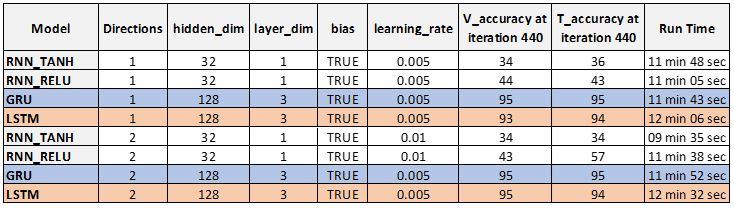

In [0]:
from IPython.display import Image, display
print('Accuracies of Final models\n')
display(Image(filename='accuracies.JPG', width=850))

Losses of GRUs and LSTMs



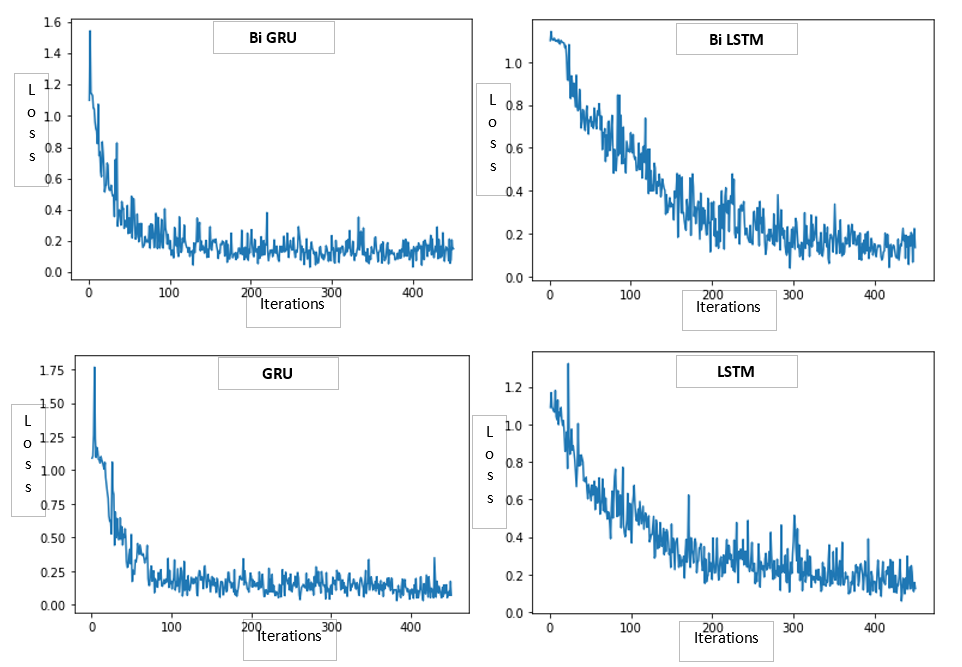

In [0]:
print('Losses of GRUs and LSTMs\n')
display(Image(filename='losses.PNG', width=850))

## Part 1.3 (20%)

RNN hidden state. In the code above in the RNNModel and BidirRecurrentModel, we utilise the final hidden state extracted by the model in order to make the final pass through a feed-forward layer towards a final prediction.

a) Can you think of reasons this might not be the best choice? Please write down two variations that could possibly yield better result.

b) Experiment with such alternative approaches in the code below in order to achieve a better result and report it below.

## Answer to Part 1.3.a :
**a)**

 What actually a hidden state represents, is an overall state of what we have seen so far. For example, if we have an NLP task, for a sentence "the cat sat on the mat." the number of hidden states would be 6. By utilising only the final hidden state extracted by the model, we may end up loosing important information as the previous hidden states may contain important information of dependancies in the sentence; the second hidden state can capture more about the dependancies in "the cat" compared to the last hidden state, while the last hidden state captures relationships whithin the whole sentence.


Instead of utilising only the final hidden state, we could utilise all the hiden states or partially some of them in order to make the final pass through a feed-forward layer towards a final prediction:

* For example, we could take the maximum of all the hidden states or of some of the hidden states (or maybe the last $k$ hidden states). (Note that this is known as **max-pooling**) The code below is what we could change in the ``` RNNModel ``` or in the ```BidirRecurrentModel ```  before making the final pass into the feed-forward network to get the maximum out of all hidden states:

```
out = outs[0].squeeze() 
for i in range(1, len(outs)):
    out = torch.max(out, outs[i]).squeeze() 
```

* An other example, would be to **average** all or the the last $k$ hidden states. The code below shows what we could change in the ``` RNNModel ``` or in the ```BidirRecurrentModel ```  before making the final pass into the feed-forward network to get the average of all hidden states:
 
```
out = outs[0].squeeze() 
for i in range(1, len(outs)):
    out = out + outs[i].squeeze() 
out = out / len(outs)
```

* An other example, would be to **sum** all or the the last $k$ hidden states. The code below shows what we could change in the ``` RNNModel ``` or in the ```BidirRecurrentModel ```  before making the final pass into the feed-forward network to get the sum of all hidden states:
 
```
out = outs[0].squeeze() 
for i in range(1, len(outs)):
    out = out + outs[i].squeeze() 
```



## Note that below, I am redefining  the ```RNNModel ``` (since that was my best model on Part 1.2) in order to get the **average or maximum out of all hidden states**. Using the same hyperparameters and the best model from Part 1.2, I will train my best model utilising the above motification.



In [0]:
## REDEFINITION OF THE RNNModel TO UTILISE ALL HIDDEN STATES
class RNNModel(nn.Module):
    def __init__(self, mode, input_size, hidden_size, num_layers, bias, output_size):
        super(RNNModel, self).__init__()
        self.mode = mode
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bias = bias
        self.output_size = output_size
        
        self.rnn_cell_list = nn.ModuleList()
        
        if mode == 'LSTM':
        ########################################################################
        ## START OF YOUR CODE
        ########################################################################
            self.rnn_cell_list.append(LSTMCell(self.input_size,
                                                self.hidden_size,
                                                self.bias))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(LSTMCell(self.hidden_size,
                                                    self.hidden_size,
                                                    self.bias))
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################


        elif mode == 'GRU':
            self.rnn_cell_list.append(GRUCell(self.input_size,
                                              self.hidden_size,
                                              self.bias))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(GRUCell(self.hidden_size,
                                                  self.hidden_size,
                                                  self.bias))

        elif mode == 'RNN_TANH':
            self.rnn_cell_list.append(BasicRNNCell(self.input_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "tanh"))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(BasicRNNCell(self.hidden_size,
                                                       self.hidden_size,
                                                       self.bias,
                                                       "tanh"))

        elif mode == 'RNN_RELU':
            self.rnn_cell_list.append(BasicRNNCell(self.input_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "relu"))
            for l in range(1, self.num_layers):
                self.rnn_cell_list.append(BasicRNNCell(self.hidden_size,
                                                   self.hidden_size,
                                                   self.bias,
                                                   "relu"))
        else:
            raise ValueError("Invalid RNN mode selected.")


        self.att_fc = nn.Linear(self.hidden_size, 1)
        self.fc = nn.Linear(self.hidden_size, self.output_size)

        
    def forward(self, input, hx=None):
        if hx is None:
            if torch.cuda.is_available():
                h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size).cuda())
            else:
                h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size))

        else:
             h0 = hx

        outs = []

        ########################################################################
        ## START OF YOUR CODE
        #########################################################################

        # Input of shape (seq_len, batch_size, input_size)
        #
        # Output of shape (batch_size, output_size)
        hidden = list()
        for layer in range(self.num_layers):
            hidden.append(h0[layer, :, :])
        
        for t in range(input.size(1)):

            for layer in range(self.num_layers):

                if self.mode == 'LSTM':
                    
                    if layer == 0:
                        hidden_l = self.rnn_cell_list[layer](
                            input[:, t, :], 
                            (hidden[layer][0],hidden[layer][1])
                            )
                    else:
                        hidden_l = self.rnn_cell_list[layer](
                            hidden[layer - 1][0], 
                            (hidden[layer][0], hidden[layer][1])
                            )

                else:

                    if layer == 0:
                        hidden_l = self.rnn_cell_list[layer](input[:, t, :], hidden[layer])
                    else:
                        hidden_l = self.rnn_cell_list[layer](hidden[layer - 1],hidden[layer])
                    hidden[layer] = hidden_l

                hidden[layer] = hidden_l

            if self.mode == 'LSTM':
                outs.append(hidden_l[0])
            else:
                outs.append(hidden_l)
   
        ########################################################################
        ## END OF YOUR CODE
        ########################################################################

        ########################################################################
        ## CODE CHANGED FROM PART 1.1
        ########################################################################

        # Utilise all hidden layers by average pooling!

        out = outs[0].squeeze() 
        for i in range(1, len(outs)):
            out = out + outs[i].squeeze()
       
        out = self.fc(out/len(outs))
        
        ########################################################################
        ## END OF CODE CHANGED FROM PART 1.1
        ########################################################################
        return out


Iteration: 20. Loss: 0.7715858221054077. V-Accuracy: 48  T-Accuracy: 50
Iteration: 40. Loss: 0.5285035371780396. V-Accuracy: 79  T-Accuracy: 80
Iteration: 60. Loss: 0.3326730728149414. V-Accuracy: 89  T-Accuracy: 89
Iteration: 80. Loss: 0.2708752453327179. V-Accuracy: 92  T-Accuracy: 91
Iteration: 100. Loss: 0.2250668704509735. V-Accuracy: 93  T-Accuracy: 90
Iteration: 120. Loss: 0.12250454723834991. V-Accuracy: 94  T-Accuracy: 94
Iteration: 140. Loss: 0.2393302470445633. V-Accuracy: 93  T-Accuracy: 94
Iteration: 160. Loss: 0.13338686525821686. V-Accuracy: 93  T-Accuracy: 94
Iteration: 180. Loss: 0.12880279123783112. V-Accuracy: 91  T-Accuracy: 94
Iteration: 200. Loss: 0.17691311240196228. V-Accuracy: 95  T-Accuracy: 95
Iteration: 220. Loss: 0.10732176154851913. V-Accuracy: 94  T-Accuracy: 95
Iteration: 240. Loss: 0.1221901923418045. V-Accuracy: 94  T-Accuracy: 95
Iteration: 260. Loss: 0.07662581652402878. V-Accuracy: 95  T-Accuracy: 95
Iteration: 280. Loss: 0.14770764112472534. V-Accu

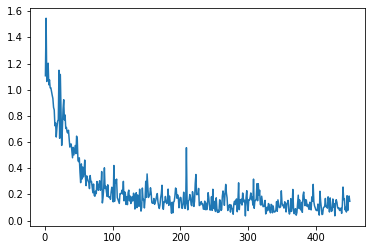

In [0]:
# Parts of experiment code based on: https://github.com/emadRad/lstm-gru-pytorch

# Add the model that has got the best results for you after after Part 1.2 and Part 1.3

seq_dim, input_dim = train_dataset[0][0].shape
output_dim = 3

## YOU MAY CONFIGURE THESE.
hidden_dim = 128
layer_dim = 3
bias = True

model = RNNModel("GRU", input_dim, hidden_dim, layer_dim, bias, output_dim)

if torch.cuda.is_available():
    model.cuda()
    
criterion = nn.CrossEntropyLoss()

## YOU MAY CONFIGURE THESE.
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_list = []
iter = 0
max_v_accuracy = 0
reported_t_accuracy = 0
max_t_accuracy = 0
for epoch in range(num_epochs):
    for i, (audio, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            audio = Variable(audio.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()

        outputs = model(audio)

        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()

        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % valid_every_n_steps == 0:
            correct = 0
            total = 0
            for audio, labels in valid_loader:
                if torch.cuda.is_available():
                    audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                else:
                    audio = Variable(audio.view(-1, seq_dim, input_dim))

                outputs = model(audio)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            v_accuracy = 100 * correct / total
            
            is_best = False
            if v_accuracy >= max_v_accuracy:
                max_v_accuracy = v_accuracy
                is_best = True

            if is_best:
                for audio, labels in test_loader:
                    if torch.cuda.is_available():
                        audio = Variable(audio.view(-1, seq_dim, input_dim).cuda())
                    else:
                        audio = Variable(audio.view(-1, seq_dim, input_dim))

                    outputs = model(audio)

                    _, predicted = torch.max(outputs.data, 1)

                    total += labels.size(0)

                    if torch.cuda.is_available():
                        correct += (predicted.cpu() == labels.cpu()).sum()
                    else:
                        correct += (predicted == labels).sum()

                t_accuracy = 100 * correct / total
                reported_t_accuracy = t_accuracy

            print('Iteration: {}. Loss: {}. V-Accuracy: {}  T-Accuracy: {}'.format(iter, loss.item(), v_accuracy, reported_t_accuracy))

plt.plot(range(1,len(loss_list)+1), loss_list)

### Answer to question Part 1.3.b
**b)**

Experimenting with the proposed variation above for the RNNModel implementation, when utilising all of the hidden states and averaging them, instead of utilising only the last hidden state, the performance of my best model is increased, as shown above. 

The Validation accuracy increased by 1 % (from 95 to 96 %) as well as the Test accuracy is also increased by 1 %, from 95 to 96 %. 

Moreover, observing the loss curves for the two models, the decrease is similar since both are GRUs and share the same number of hyperparameters (same layer_dim and hidden_dim).

While I was also experimenting with a redefinition of the BiLSTM it also yielded higher accuracy results compared to the BiLSTM of Part 1.2 (96 %  V_Accuracy and 96 % T_Accuracy compared to 95 % and 94 % respectively).

## Part 2: Theoretical questions (30%)

Please answer the following theoretical questions in a cell below each respective question.

a. What is the _vanishing and exploding gradients problem_? When does it appear, and what is its practical significance? Please explain. (10%)

* In machine learning, the vanishing and exploding gradients problem is an issue found in training artificial deep neural networks with gradient-based learning methods and backpropagation (usually through Gradient Descent).

* The **vanishing  gradients problem** refers to the situation spotted during training where the gradients of the loss function with respect to the network's parameters approach zero and become too small. 
Therefore, when updating, if the gradients are neglible, the network's parameters are not actually updated and hence the network stops learning. 

* Respectively, the **exploding gradients problem** refers to the phenomenon where the gradients of the loss functions with respect to the network's parameters are too large and result in very large and uncontrolled updates to the network's parameters. 

* The problem occurs when many transformations (i.e Sigmoid, ReLU, Tanh, etc) are applied sequentially to the input. For example, using the hyperbolic tangent function (which squishes values in (-1,1)) as an activation _n_-times sequentially, this will result in multypling _n_ small or large numbers sequentially, making the magnitude of the update decrease/increase exponentially.

* Both of the above, result in making the learning process hard and unstable and consequently, making the network hard or even unable to train. The vanishing and exploding gradients problems are caused by **repeatedly** multypling many small/large gradients at the stage of backpropagation. 

* This problem can affect especially Reccurent Neural Networks as the same activation is applied to the input data sequentially. 

b. The following (cartoon) plots show the gradients and the training curves for three models A, B, and C, trained on the same dataset. The three models are a RNN, a LSTM and a GRU, not necessarily in that order. (10%)

* Which could plausibly be which? Why? Please explain your reasoning.
* For which kinds of problems would you elect to use each of them?

In [0]:
cd /content/drive/"My Drive"/"Colab Notebooks"/"Deep Learning"/cw_3

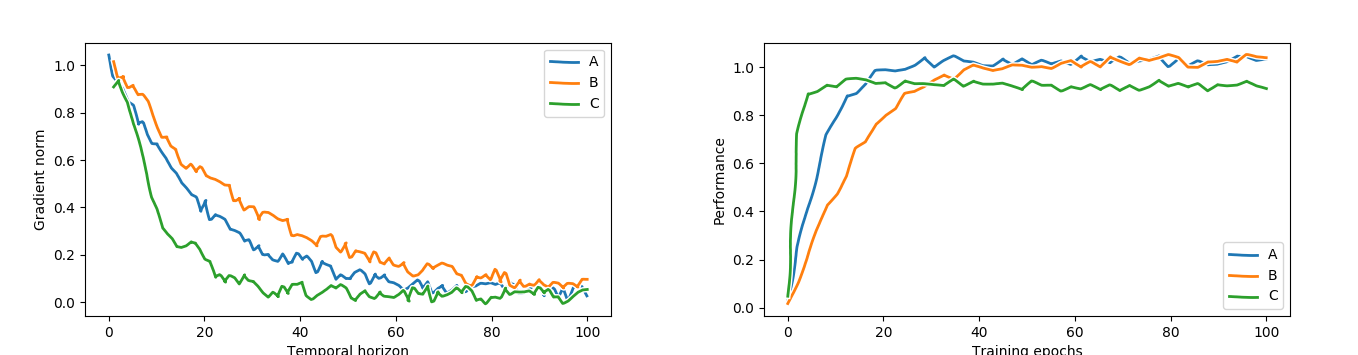

In [0]:
from IPython.display import Image, display
display(Image(filename='question_figs.png', width=850))

* First of all, observing the graph on the left we can deduce that **C** illustrates an **RNN** model since the gradients vanish (decrease) earlier and faster than for the other two models. This happens due to the fact that RNNs don't have forget gates the help fight the vanishing gradients problem, whilist LSTMs and GRUs have. Furthermore, observing the graph on the right we can also motice that model **C** performs more poorly compared to **A** and **B** which also reinforces the argument that the model **C** is an RNN.

* As for **A** and **B**, from the graph on the right, we can infer that **A** represents the GRU model as it requires less training epochs to reach a good performance score than **B**. This is due to that fact that GRUs have less training parameters (0.25 % less ) than LSTMs, and thus the can be trained faster.  

Therefore:
* **A** illustrates a GRU 
* **B** illustrates an LSTM 
* **C** illustrates an RNN

Generally, GRUs and LSTMs have a lot more parameters to train than RNNs, thus, if a problem is less complicated, i.e. there are not long-term temporal dependancies among its data, then probably RNNs would be the way to go.

Now, if the task requires learning long-term temporal dependenciehas (i.e. machine translation), then GRUs and LSTMs can perfom way better than RNNs, as they can deal with the vanishing/exploding gradients problem.

Between GRUs and LSTMs, GRUs have less training parameters and are simpler than LSTMs and thus they can be trained faster and be modified easier than LSTMs. However, LSTMs could be used on more stiff tasks since they train more parameters and could perform better on tasks that require long-term dependancies as they have a separate memory cell.



c.  Write down five possible Connectionist Temporal Classification (CTC) paths (of no more than a length of eight) that correspond to the same label "LADDER". (10%)

Five possible Connectionist Temporal Classification (CTC) paths (of no more than a length of eight) that correspond to the label "LADDER" are:
* $\emptyset$ L A D $\emptyset$ D E R --> LADDER
* L A A D $\emptyset$ D E R --> LADDER
* L A D $\emptyset$ D E R R --> LADDER
* L $\emptyset$ A  D $\emptyset$ D E R --> LADDER
* L A D $\emptyset$ D $\emptyset$ E R --> LADDER